# Regularization in Machine Learning

## Objectives
- Understand what regularization is and why it is needed in machine learning models.
- Learn the mathematical intuition behind L1 (Lasso), L2 (Ridge), and Elastic Net penalties.
- Implement L2-regularized logistic regression from scratch using NumPy.
- Compare a from-scratch implementation with Scikit-learn's `LogisticRegression`.
- Visualize the effect of regularization strength on model accuracy and weight magnitudes.

## Prerequisites
- Basic Python and NumPy.
- Basic understanding of logistic regression and gradient descent.
- Familiarity with classification metrics (accuracy, precision, recall, F1-score).

## Dataset
We use the classic **Iris** dataset, loaded directly via `sklearn.datasets.load_iris`.

- Kaggle link (same dataset, for reference): https://www.kaggle.com/datasets/uciml/iris

## Credits
Notebook prepared as part of an ML curriculum series on core algorithms and best practices.

---
### Why we are doing this
Every notebook needs a consistent, well-documented set of tools before any analysis can begin. Importing libraries up front (with comments) makes the rest of the notebook easy to follow.

### What the code below does
Imports NumPy, Pandas, plotting libraries, and the specific Scikit-learn modules used throughout this notebook (dataset loader, train/test split, scaler, logistic regression, and evaluation metrics). It also sets a global random seed for reproducibility.

### What you should expect to see
No output — this cell only sets up the environment. If it runs without errors, all required libraries are available.


In [1]:
# ---------------------------------------------------------
# IMPORTS
# ---------------------------------------------------------

import numpy as np                      # Numerical operations and array handling
import pandas as pd                     # DataFrames for tabular data exploration

import matplotlib.pyplot as plt         # Plotting library for visualizations
import seaborn as sns                   # Statistical plotting (used for styling/heatmaps)

from sklearn.datasets import load_iris               # Loads the real-world Iris dataset
from sklearn.model_selection import train_test_split # Splits data into train/test sets
from sklearn.preprocessing import StandardScaler     # Standardizes features (mean=0, std=1)
from sklearn.linear_model import LogisticRegression  # Scikit-learn's regularized logistic regression
from sklearn.metrics import (
    accuracy_score,        # Computes classification accuracy
    classification_report, # Prints precision, recall, F1-score per class
    confusion_matrix        # Computes the confusion matrix
)

sns.set_style("whitegrid")  # Clean grid style for all seaborn/matplotlib plots

# Set a global random seed for reproducibility.
# INTERVIEW NOTE: Even though this notebook mostly uses deterministic
# operations, seeding NumPy ensures any random step (e.g., weight
# initialization later) is reproducible across runs.
np.random.seed(42)


## Part 1: Theory Recap

- **What is Regularization?** Regularization is a technique that adds a penalty term to a model's loss function based on the magnitude of its weights, discouraging the model from relying too heavily on any single feature.
- **Why is it needed?** Without regularization, models with many features or high capacity tend to fit noise in the training data, leading to poor performance on unseen data.
- **Overfitting:** Overfitting occurs when a model learns the training data (including its noise) so well that it fails to generalize to new, unseen data — regularization is one of the main tools to combat this.
- **L1 (Lasso) Regularization:** Adds the sum of the absolute values of the weights to the loss function; it tends to push some weights exactly to zero, effectively performing feature selection.
- **L2 (Ridge) Regularization:** Adds the sum of the squared weights to the loss function; it shrinks all weights toward zero smoothly but rarely makes them exactly zero.
- **Elastic Net:** A combination of L1 and L2 penalties, controlled by a mixing parameter, that balances feature selection (from L1) with weight shrinkage (from L2).

# INTERVIEW NOTE: A common interview question is "Why does L1 produce sparse solutions but L2 doesn't?" — the geometric intuition is that the L1 penalty's diamond-shaped constraint region has corners on the axes, making it likely that the optimal solution lands exactly on an axis (a zero weight).


## Part 2: Load the Real-World Dataset

We load the **Iris** dataset using `sklearn.datasets.load_iris`. This is a real-world dataset of 150 flower samples from three species (*setosa*, *versicolor*, *virginica*), each described by four measurements: sepal length, sepal width, petal length, and petal width.

- **Kaggle reference:** https://www.kaggle.com/datasets/uciml/iris

We convert it into a Pandas DataFrame and inspect it with `.head()`, `.info()`, and `.describe()` to understand the features (the four numeric measurements) and the target (the species label, encoded as 0, 1, or 2).

### Why we are doing this
Before building any model, we need to load a real dataset and understand its structure — the number of samples, features, data types, and basic statistics.

### What the code below does
Loads the Iris dataset from `sklearn.datasets`, converts it into a Pandas DataFrame, and prints `.head()`, `.info()`, and `.describe()` to inspect the data.

### What you should expect to see
A table of the first 5 rows (4 numeric features + target), a summary showing 150 non-null rows across 5 columns, and descriptive statistics (mean, std, min, max, etc.) for each numeric column.


In [2]:
# Load the Iris dataset from sklearn (real-world data, not synthetic)
iris = load_iris()

# Build a DataFrame combining features and target for easy exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Inspect the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Inspect column types and non-null counts
print("\\nDataset info:")
df.info()

# Inspect summary statistics for each numeric feature
print("\\nSummary statistics:")
display(df.describe())

print("\\nFeatures:", iris.feature_names)
print("Target classes:", iris.target_names)


First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


\nDataset info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
\nSummary statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


\nFeatures: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


## Part 2 (continued): Preprocessing

Before modeling, we perform basic data quality checks:

- Check for missing values (`isnull()`), since regularized models can be sensitive to NaNs.
- Check for duplicate rows, which could bias training if not handled.
- Split the DataFrame into the feature matrix `X` and target vector `y`, then create train/test sets for fair evaluation.

### Why we are doing this
Real-world datasets can contain missing values or duplicate rows that may bias training. We also need to split the data into features/target and train/test sets before modeling.

### What the code below does
Checks for nulls and duplicate rows, separates features (`X`) and target (`y`), performs an 80/20 stratified train/test split, and standardizes the features with `StandardScaler`.

### What you should expect to see
The notebook will display the number of missing values and duplicate rows detected in the dataset, along with the training and testing shapes after preprocessing.


In [3]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\\nNumber of duplicate rows:", df.duplicated().sum())

# Separate features (X) and target (y)
X = df[iris.feature_names].values
y = df['target'].values

# Split into training and test sets (80/20 split), stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features: regularization penalizes weight magnitude, so features
# must be on comparable scales for the penalty to be meaningful
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\\nTraining set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64
\nNumber of duplicate rows: 1
\nTraining set shape: (120, 4)
Test set shape: (30, 4)


## Part 3: The Penalty Concept

In ordinary logistic regression, we minimize a loss function (e.g., cross-entropy) over the training data. **Regularization modifies this objective** by adding a penalty term proportional to the size of the model's weights:

> Regularized Loss = Data Loss + λ × Penalty(weights)

Here, **λ (lambda)** controls how strongly we penalize large weights:
- A **large λ** forces weights to be small, producing a simpler model (risk of underfitting).
- A **small λ** allows weights to grow, producing a more flexible model (risk of overfitting).

In the following from-scratch implementation, we focus on the **L2 penalty**, defined as λ × Σ(wᵢ²), and apply it to a simple linear scoring function for a binary classification subset of Iris (class 0 vs. the rest), so the math stays clear and interpretable.

# INTERVIEW NOTE: Be ready to explain that λ (lambda) in textbooks corresponds to the inverse of `C` in Scikit-learn's `LogisticRegression` — a smaller `C` means stronger regularization.

### Why we are doing this
To truly understand L2 regularization, we implement it manually with NumPy rather than relying on a library — this builds intuition for how the penalty term affects gradient updates.

### What the code below does
Defines a sigmoid function, a prediction function, and a loss function that includes an L2 penalty. Then it trains a binary logistic regression model (class "setosa" vs. rest) using manual gradient descent for 500 epochs.

### What you should expect to see
A printed "Training complete." message followed by the final learned weight vector (4 values, one per feature) and a final bias value. No errors or warnings.


In [4]:
# ---------------------------------------------------------
# NUMPY FROM-SCRATCH: L2-REGULARIZED LOGISTIC REGRESSION (BINARY)
# ---------------------------------------------------------
# To keep the math simple and interpretable, we create a binary task:
# class 0 ("setosa") vs. all other classes (1).
y_train_binary = (y_train == 0).astype(float)
y_test_binary = (y_test == 0).astype(float)

n_features = X_train_scaled.shape[1]

# INTERVIEW NOTE: We seed NumPy for reproducible weight initialization
np.random.seed(42)

# Initialize weights and bias randomly (small values for stable training)
weights = np.random.randn(n_features) * 0.01
bias = 0.0

# Hyperparameters
learning_rate = 0.1
lambda_l2 = 0.1   # Regularization strength (lambda)
n_epochs = 500

def sigmoid(z):
    # Sigmoid function maps any real value to the (0, 1) range -> probability
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w, b):
    # Linear combination of inputs and weights, plus bias -> raw score
    z = np.dot(X, w) + b
    # Pass raw score through sigmoid to get a probability
    return sigmoid(z)

def compute_loss(X, y, w, b, lam):
    m = X.shape[0]
    y_pred = predict_proba(X, w, b)
    eps = 1e-15  # Small constant to avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)

    # Binary cross-entropy loss (data loss)
    data_loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    # INTERVIEW NOTE: The bias term is NOT regularized; only weights are penalized
    l2_penalty = lam * np.sum(w ** 2)

    # Total regularized loss = data loss + L2 penalty
    regularized_loss = data_loss + l2_penalty
    return data_loss, l2_penalty, regularized_loss

# Gradient descent training loop
for epoch in range(n_epochs):
    y_pred = predict_proba(X_train_scaled, weights, bias)

    # Gradient of cross-entropy loss w.r.t. weights and bias
    error = y_pred - y_train_binary
    grad_w = np.dot(X_train_scaled.T, error) / X_train_scaled.shape[0]
    grad_b = np.mean(error)

    # Add gradient of the L2 penalty term: d/dw [lambda * w^2] = 2 * lambda * w
    grad_w += 2 * lambda_l2 * weights

    # Update parameters using gradient descent
    weights -= learning_rate * grad_w
    bias -= learning_rate * grad_b

print("Training complete.")
print("Final weights:", np.round(weights, 4))
print("Final bias:", round(bias, 4))


Training complete.
Final weights: [-0.4421  0.4429 -0.6275 -0.5918]
Final bias: -1.0895


## Evaluating the From-Scratch Model

### Why we are doing this
A trained model is only useful if we check how well it performs on unseen data. We also want to break down the loss into its data-fit and penalty components to see the effect of regularization explicitly.

### What the code below does
Uses the trained weights/bias to generate predictions and probabilities on the test set, then prints sample predictions vs. true labels and a breakdown of the regularized loss (data loss, L2 penalty, total).

### What you should expect to see
Sample predicted classes that closely match the true classes, a loss breakdown with three numeric values (data loss, L2 penalty, regularized loss), and a from-scratch test accuracy close to 1.0 for this easy binary task.


In [5]:
# ---------------------------------------------------------
# EVALUATE THE NUMPY FROM-SCRATCH MODEL
# ---------------------------------------------------------

# Compute predictions (probabilities) on the test set
test_probs = predict_proba(X_test_scaled, weights, bias)
test_preds = (test_probs >= 0.5).astype(int)

print("Sample predictions (probabilities):", np.round(test_probs[:10], 4))
print("Sample predicted classes:          ", test_preds[:10])
print("Sample true classes:               ", y_test_binary[:10].astype(int))

# Compute loss components on the test set
data_loss, l2_penalty, reg_loss = compute_loss(X_test_scaled, y_test_binary, weights, bias, lambda_l2)

print("\\n--- Loss Breakdown (Test Set) ---")
print(f"Data loss (cross-entropy):  {data_loss:.4f}")
print(f"L2 penalty:                 {l2_penalty:.4f}")
print(f"Regularized loss (total):   {reg_loss:.4f}")

# Test set accuracy for this scratch model
scratch_accuracy = np.mean(test_preds == y_test_binary)
print(f"\\nFrom-scratch test accuracy: {scratch_accuracy:.4f}")


Sample predictions (probabilities): [0.7836 0.1053 0.2874 0.2573 0.8153 0.1517 0.868  0.7336 0.0682 0.1987]
Sample predicted classes:           [1 0 0 0 1 0 1 1 0 0]
Sample true classes:                [1 0 0 0 1 0 1 1 0 0]
\n--- Loss Breakdown (Test Set) ---
Data loss (cross-entropy):  0.1636
L2 penalty:                 0.1136
Regularized loss (total):   0.2772
\nFrom-scratch test accuracy: 1.0000


## Part 4: Advantages of Scikit-learn's Implementation

While the from-scratch implementation builds intuition, Scikit-learn's `LogisticRegression` offers several practical advantages:

- **Optimized solvers** (e.g., `lbfgs`, `liblinear`) that converge faster and more reliably than basic gradient descent.
- **Built-in support for multi-class classification** (handling all three Iris classes directly, instead of a binary subset).
- **Easy control of regularization strength** via the `C` parameter (inverse of λ), plus support for L1, L2, and Elastic Net penalties.
- **Production-ready, well-tested code** with consistent APIs for `fit`, `predict`, and `predict_proba`.

### Why we are doing this
Now that we understand regularization manually, we use Scikit-learn's optimized, production-ready implementation to compare strong vs. weak regularization on the full 3-class problem.

### What the code below does
Trains two `LogisticRegression` models — one with strong regularization (`C=0.01`) and one with weak regularization (`C=100`) — then prints accuracy, a classification report, and a confusion matrix for each.

### What you should expect to see
Two sets of metrics. The strongly regularized model (C=0.01) typically has lower accuracy with more confusion between "versicolor" and "virginica", while the weakly regularized model (C=100) typically achieves very high (often perfect) accuracy on this simple dataset.


In [6]:
# ---------------------------------------------------------
# SCIKIT-LEARN: COMPARE STRONG vs. WEAK REGULARIZATION
# ---------------------------------------------------------
# Recall: C is the INVERSE of regularization strength.
# Large C  -> weak regularization (closer to unregularized model)
# Small C  -> strong regularization (heavily penalized weights)

# Strong regularization (C = 0.01) on the full 3-class Iris problem
model_strong_reg = LogisticRegression(C=0.01, max_iter=1000, random_state=42)
model_strong_reg.fit(X_train_scaled, y_train)
preds_strong = model_strong_reg.predict(X_test_scaled)

# Weak regularization (C = 100)
model_weak_reg = LogisticRegression(C=100, max_iter=1000, random_state=42)
model_weak_reg.fit(X_train_scaled, y_train)
preds_weak = model_weak_reg.predict(X_test_scaled)

# --- Results for C = 0.01 (strong regularization) ---
print("===== LogisticRegression(C=0.01) — Strong Regularization =====")
print("Accuracy:", accuracy_score(y_test, preds_strong))
print("\\nClassification Report:")
print(classification_report(y_test, preds_strong, target_names=iris.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, preds_strong))

# --- Results for C = 100 (weak regularization) ---
print("\\n===== LogisticRegression(C=100) — Weak Regularization =====")
print("Accuracy:", accuracy_score(y_test, preds_weak))
print("\\nClassification Report:")
print(classification_report(y_test, preds_weak, target_names=iris.target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, preds_weak))


===== LogisticRegression(C=0.01) — Strong Regularization =====
Accuracy: 0.8
\nClassification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      0.50      0.62        10
   virginica       0.64      0.90      0.75        10

    accuracy                           0.80        30
   macro avg       0.83      0.80      0.79        30
weighted avg       0.83      0.80      0.79        30

Confusion Matrix:
[[10  0  0]
 [ 0  5  5]
 [ 0  1  9]]
\n===== LogisticRegression(C=100) — Weak Regularization =====
Accuracy: 1.0
\nClassification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00  

## Visualizing the Effect of Regularization

### Why we are doing this
Numbers alone can be hard to compare quickly. Visualizing accuracy and weight magnitudes side-by-side makes the effect of the regularization strength `C` immediately intuitive.

### What the code below does
Creates two plots: (1) a bar chart comparing test accuracy for strong vs. weak regularization, and (2) a bar chart comparing the mean absolute weight (coefficient) magnitude per feature for both settings.

### What you should expect to see
Plot 1: two bars showing test accuracy, each labeled with its exact value — the weakly regularized model (C=100) usually shows equal or higher accuracy.
Plot 2: grouped bars per feature showing that the strongly regularized model (C=0.01) has noticeably smaller weight magnitudes than the weakly regularized model (C=100), illustrating how regularization shrinks weights.


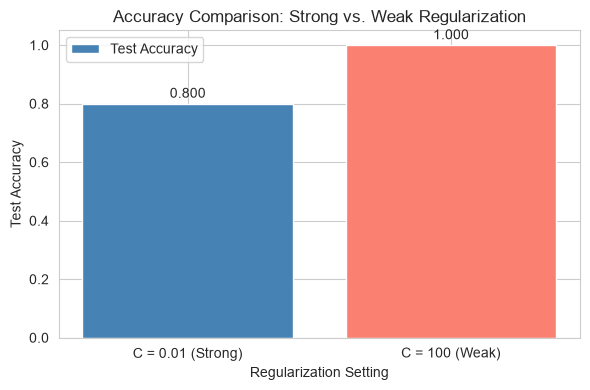

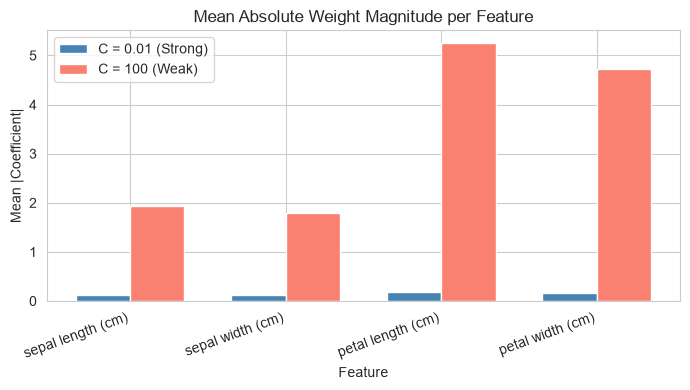

In [7]:
# ---------------------------------------------------------
# VISUALIZATIONS
# ---------------------------------------------------------

# Plot 1: Accuracy comparison between strong and weak regularization
acc_strong = accuracy_score(y_test, preds_strong)
acc_weak = accuracy_score(y_test, preds_weak)

plt.figure(figsize=(6, 4))
bars = plt.bar(['C = 0.01 (Strong)', 'C = 100 (Weak)'], [acc_strong, acc_weak],
               color=['steelblue', 'salmon'], label='Test Accuracy')
plt.title('Accuracy Comparison: Strong vs. Weak Regularization')
plt.xlabel('Regularization Setting')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05)
for bar, acc in zip(bars, [acc_strong, acc_weak]):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.3f}", ha='center')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Weight magnitude comparison (mean |coefficient| per class)
mean_abs_weights_strong = np.mean(np.abs(model_strong_reg.coef_), axis=0)
mean_abs_weights_weak = np.mean(np.abs(model_weak_reg.coef_), axis=0)

x_pos = np.arange(len(iris.feature_names))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x_pos - width/2, mean_abs_weights_strong, width, label='C = 0.01 (Strong)', color='steelblue')
plt.bar(x_pos + width/2, mean_abs_weights_weak, width, label='C = 100 (Weak)', color='salmon')
plt.title('Mean Absolute Weight Magnitude per Feature')
plt.xlabel('Feature')
plt.ylabel('Mean |Coefficient|')
plt.xticks(x_pos, iris.feature_names, rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


## Part 5: Hyperparameters

Key hyperparameters that control regularization behavior:

- **`C` (Scikit-learn):** The inverse of regularization strength. Smaller values specify stronger regularization (more penalty on large weights); larger values specify weaker regularization.
- **`alpha`:** Used in models like `Ridge`, `Lasso`, and `ElasticNet` directly as the regularization strength multiplier — larger `alpha` means stronger regularization (this is the direct opposite scaling of `C`).
- **`lambda` (λ):** The general textbook symbol for regularization strength, used in the loss function as `Loss + λ * Penalty`. In Scikit-learn's logistic regression, `λ ≈ 1 / C`.
- **`max_iter`:** The maximum number of iterations the optimizer is allowed to run before stopping. With strong regularization or poorly scaled features, the optimizer may need more iterations to converge; setting it too low can produce a `ConvergenceWarning`.

### Why we are doing this
A single comparison (C=0.01 vs. C=100) only shows two extremes. To truly understand the trend, we sweep across multiple values of `C` and observe how accuracy and weight magnitude change together.

### What the code below does
Trains a `LogisticRegression` model for each value of `C` in a small list (`[0.001, 0.01, 0.1, 1, 10, 100]`), then records test accuracy and the mean absolute weight magnitude for each. Results are shown in a table.

### INTERVIEW NOTE
This loop trains 6 lightweight models on a tiny dataset (150 rows, 4 features), so it runs almost instantly — no expensive computation is added.

### What you should expect to see
A table with 6 rows. As `C` increases (weaker regularization), the "Mean |Weight|" column should generally increase, while "Test Accuracy" tends to rise and then plateau near 1.0 for larger `C` on this simple dataset.


In [8]:
# ---------------------------------------------------------
# EXPERIMENT: VARY C ACROSS MULTIPLE VALUES
# ---------------------------------------------------------

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    avg_weight_magnitude = np.mean(np.abs(model.coef_))
    results.append((c, acc, avg_weight_magnitude))

# Display results as a DataFrame for clarity
results_df = pd.DataFrame(results, columns=['C', 'Test Accuracy', 'Mean |Weight|'])
print("Effect of C on Accuracy and Weight Magnitude:")
display(results_df)

# INTERVIEW NOTE: Notice how mean |weight| generally increases as C increases
# (weaker regularization), while accuracy may plateau or fluctuate slightly
# once the model has enough capacity to fit the data well.


Effect of C on Accuracy and Weight Magnitude:


,C,Test Accuracy,Mean |Weight|
0,0.001,0.766667,0.026302
1,0.010,0.800000,0.144836
2,0.100,0.866667,0.436571
3,1.000,0.933333,1.101745
4,10.000,1.000000,2.100994
5,100.000,1.000000,3.422342


## Part 6: Interview Corner

**Q1: What is Regularization?**
Regularization is a set of techniques that add a penalty term to a model's loss function based on the size of its parameters, discouraging overly complex models and improving generalization to unseen data.

**Q2: Why is Regularization needed?**
Without it, models — especially those with many parameters relative to the amount of training data — can fit noise in the training set, leading to high variance and poor performance on new data. Regularization constrains the parameter space to favor simpler, more generalizable solutions.

**Q3: L1 vs. L2 — what's the difference?**
L1 (Lasso) adds the sum of absolute weight values as a penalty and tends to drive some weights exactly to zero, effectively performing feature selection. L2 (Ridge) adds the sum of squared weight values and shrinks all weights toward zero smoothly, but rarely to exactly zero. L1 is preferred when feature selection or sparsity is desired; L2 is preferred when all features are believed to contribute and multicollinearity is a concern.

**Q4: What is Elastic Net?**
Elastic Net combines L1 and L2 penalties using a mixing parameter (often called `l1_ratio`), allowing the model to enjoy both the sparsity benefits of L1 and the stability benefits of L2 — particularly useful when features are correlated.

**Q5: What is Overfitting?**
Overfitting occurs when a model learns patterns specific to the training data (including noise and outliers) so closely that it performs well on training data but poorly on unseen test data.

**Q6: What is the Bias-Variance Tradeoff?**
Bias is the error from overly simplistic assumptions (underfitting), while variance is the error from sensitivity to small fluctuations in the training data (overfitting). Regularization increases bias slightly (by constraining the model) in exchange for a larger reduction in variance, often improving overall test performance — this balance is the bias-variance tradeoff.


## Key Takeaways

- Regularization adds a penalty on model weight magnitudes to the loss function, helping prevent overfitting and improve generalization.
- L1 (Lasso) encourages sparse models by driving some weights to exactly zero, while L2 (Ridge) shrinks all weights smoothly without eliminating them.
- Elastic Net blends L1 and L2 penalties to combine feature selection with stability on correlated features.
- In Scikit-learn, the `C` parameter is the inverse of regularization strength — smaller `C` means stronger regularization and typically smaller weight magnitudes.
- Regularization directly addresses the bias-variance tradeoff: it slightly increases bias but can substantially reduce variance, often improving performance on unseen data.
